# Análise Exploratória da Carga Elétrica

## 1. Contexto do Projeto

Depois de entender e consolidar os dados, vamos iniciar a análise exploratória.

A carga elétrica representa a potência média que o sistema precisou atender em determinado período. Neste dataset, cada registro mostra a carga média de um subsistema durante uma hora, medida em MWmed.

Serão analisados os subsistemas Norte, Nordeste, Sul e Sudeste entre os anos de 2000 e 2025. Os dados foram disponibilizados pelo Operador Nacional do Sistema Elétrico, o ONS.

## 2. Objetivo da Análise

O objetivo deste notebook é entender como a carga elétrica se comportou ao longo do período.

Durante a análise, vamos buscar respostas para as seguintes perguntas:

- Como a carga evoluiu ao longo dos anos?
- Quais subsistemas possuem as maiores cargas?
- Os comportamentos regionais são diferentes?
- Quais meses, dias e horários apresentam maior ou menor carga?
- Existe diferença entre dias úteis e finais de semana?
- Quais registros se destacam entre os maiores e os menores valores?
- A variação da carga mudou com o passar dos anos?

Além dos gráficos, também serão utilizadas medidas estatísticas para resumir a posição, a distribuição e a dispersão dos dados.

Este projeto não terá previsão nem modelos de Machine Learning. A próxima etapa será apenas o diagnóstico estatístico da série temporal.

## 3. Importação das Bibliotecas e Carregamento dos Dados


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

DATA_PATH = Path('../data/processed')

electric_data = pd.read_parquet(DATA_PATH / 'curva_carga_consolidado.parquet')

In [2]:
electric_data.head()

,id_subsistema,nom_subsistema,din_instante,val_cargaenergiahomwmed
0,N,NORTE,2000-01-01 00:00:00,2373.7
1,NE,NORDESTE,2000-01-01 00:00:00,5340.2
2,S,SUL,2000-01-01 00:00:00,5777.0
3,SE,SUDESTE,2000-01-01 00:00:00,21183.0
4,N,NORTE,2000-01-01 01:00:00,2331.6


In [3]:
electric_data.info(memory_usage = 'deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 911608 entries, 0 to 911607
Data columns (total 4 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   id_subsistema            911608 non-null  object        
 1   nom_subsistema           911608 non-null  object        
 2   din_instante             911608 non-null  datetime64[ns]
 3   val_cargaenergiahomwmed  911348 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 105.4 MB


In [4]:
print(f'O dataset possui um total de {electric_data.shape[0]} linhas e {electric_data.shape[1]} colunas.')

O dataset possui um total de 911608 linhas e 4 colunas.


In [5]:
print(
    f"Período analisado: {electric_data['din_instante'].min()} "
    f"até {electric_data['din_instante'].max()}"
)

Período analisado: 2000-01-01 00:00:00 até 2025-12-31 23:00:00


In [6]:
electric_data[['id_subsistema', 'nom_subsistema']].drop_duplicates().sort_values('id_subsistema')

,id_subsistema,nom_subsistema
0,N,NORTE
1,NE,NORDESTE
2,S,SUL
3,SE,SUDESTE


O dataset possui registros dos quatro subsistemas entre 2000 e 2025.

Os tipos das colunas, os valores ausentes, as duplicidades e a continuidade dos horários já foram verificados no notebook anterior. Por isso, a partir de agora vamos focar no comportamento da carga elétrica.

## 4. Panorama Estatístico da Carga Elétrica

Primeiro, vamos calcular algumas medidas estatísticas para cada subsistema.

Essa visão inicial ajudará a comparar o tamanho das cargas, a faixa dos valores e a variação existente em cada região. Como estamos utilizando os 26 anos juntos, as mudanças ao longo do tempo ainda serão analisadas separadamente.


In [7]:
view_describe = electric_data.groupby(['id_subsistema', 'nom_subsistema'])['val_cargaenergiahomwmed'].describe().round(2)
view_describe

,,count,mean,std,min,25%,50%,75%,max
id_subsistema,nom_subsistema,,,,,,,,
N,NORTE,227837.0,4592.68,1670.83,610.40,3275.08,4284.52,5640.59,10239.23
NE,NORDESTE,227837.0,8886.53,2478.98,149.86,6826.40,8768.52,10710.88,18156.97
S,SUL,227837.0,9737.16,2860.97,3615.83,7621.37,9392.76,11762.64,22737.44
SE,SUDESTE,227837.0,33826.25,7625.22,7970.58,28174.30,33508.33,39214.42,62149.88


O primeiro resultado mostra uma diferença grande entre os subsistemas.

O Sudeste possui a maior média, mediana e os maiores quartis. O Norte aparece com os menores valores, enquanto Sul e Nordeste ficam entre os dois.

Em todos os subsistemas, a média está um pouco acima da mediana. Isso pode indicar influência das cargas mais altas, mas precisamos observar os histogramas antes de falar sobre o formato das distribuições.

O Sudeste também possui o maior desvio-padrão em valor absoluto. Porém, como sua carga média é muito maior, ainda não podemos dizer que ele é o mais variável proporcionalmente.

A quantidade count mostra 227.837 cargas válidas em cada subsistema. O método describe não considera os valores nulos, então essa igualdade não garante que todos possuam exatamente os mesmos horários.

### 4.1. Medidas Adicionais de Dispersão

Para comparar melhor a variação entre subsistemas de tamanhos diferentes, vamos calcular mais quatro medidas:

- variância: mostra o afastamento dos valores em relação à média;
- amplitude: diferença entre o maior e o menor valor;
- intervalo interquartil: diferença entre o primeiro e o terceiro quartil;
- coeficiente de variação: compara o desvio-padrão com a média de cada subsistema.


In [8]:
view_describe['variancia'] = view_describe['std'] ** 2
view_describe['amplitude'] = view_describe['max'] - view_describe['min']
view_describe['iqr'] = view_describe['75%'] - view_describe['25%']
view_describe['cv_%'] = (view_describe['std'] / view_describe['mean'] * 100)

view_describe.round(2)

,,count,mean,std,min,25%,50%,75%,max,variancia,amplitude,iqr,cv_%
id_subsistema,nom_subsistema,,,,,,,,,,,,
N,NORTE,227837.0,4592.68,1670.83,610.40,3275.08,4284.52,5640.59,10239.23,2791672.89,9628.83,2365.51,36.38
NE,NORDESTE,227837.0,8886.53,2478.98,149.86,6826.40,8768.52,10710.88,18156.97,6145341.84,18007.11,3884.48,27.90
S,SUL,227837.0,9737.16,2860.97,3615.83,7621.37,9392.76,11762.64,22737.44,8185149.34,19121.61,4141.27,29.38
SE,SUDESTE,227837.0,33826.25,7625.22,7970.58,28174.30,33508.33,39214.42,62149.88,58143980.05,54179.30,11040.12,22.54


As medidas absolutas acompanham o tamanho das cargas. Por isso, o Sudeste possui a maior variância, amplitude e intervalo interquartil.

Quando fazemos a comparação proporcional pelo coeficiente de variação, o resultado muda. O Norte apresenta o maior valor, com 36,38%. Depois aparecem Sul, com 29,38%, Nordeste, com 27,90%, e Sudeste, com 22,54%.

Dessa forma, o Norte possui a maior dispersão em relação à própria média. O Sudeste tem a maior dispersão em MWmed, mas a menor variação proporcional.

Como todos os anos ainda estão juntos, parte dessa diferença pode ter sido causada pelo crescimento da carga durante o período. Vamos verificar isso mais adiante.

Outro ponto que chamou atenção foi o valor mínimo de 149,86 MWmed no Nordeste, muito distante do primeiro quartil de 6.826,40 MWmed. Ainda não sabemos se esse registro é um erro ou uma ocorrência real. Ele será analisado junto com os menores valores.

## 5. Distribuição da Carga Elétrica

As medidas anteriores resumem os dados, mas não mostram onde os valores estão mais concentrados.

Agora, vamos criar um histograma para cada subsistema e observar o formato de suas distribuições.


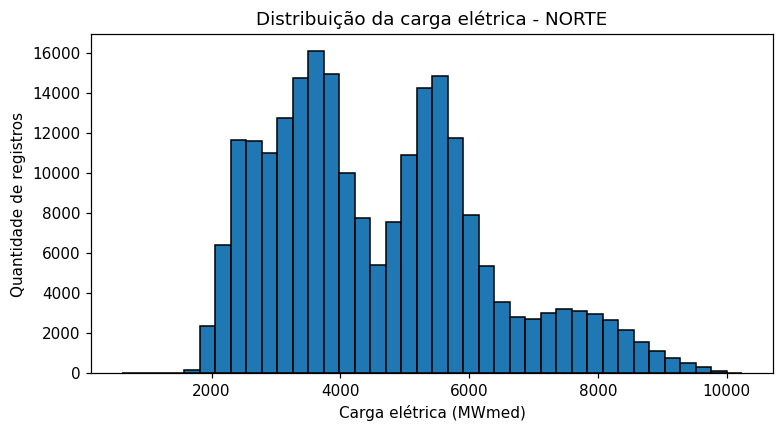

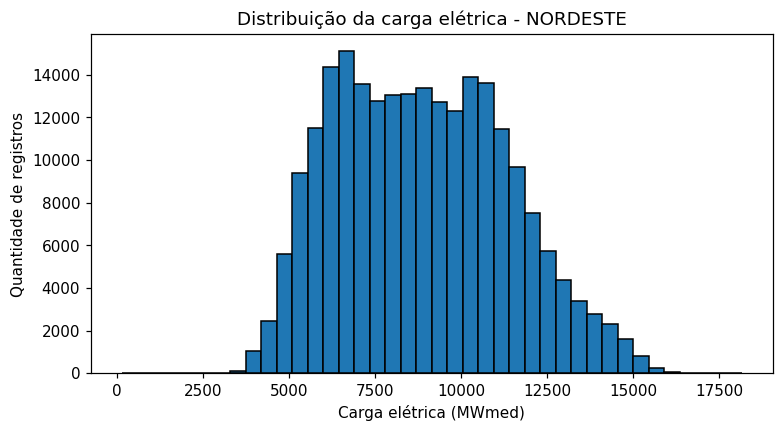

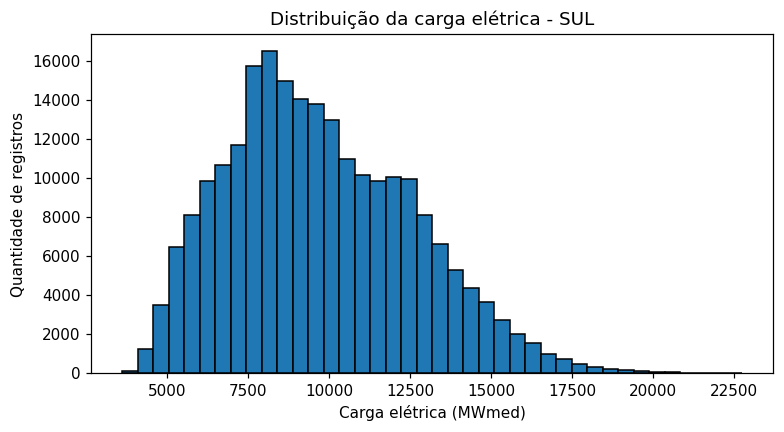

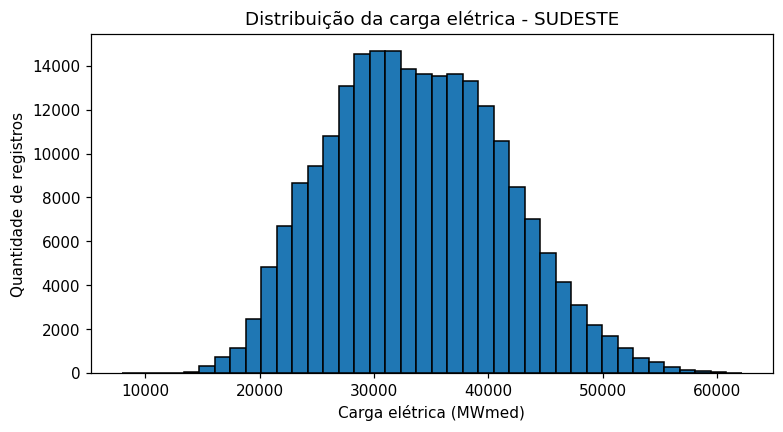

In [9]:
for subsystem in electric_data['nom_subsistema'].unique():

    subsystem_load = electric_data.loc[
        electric_data['nom_subsistema'] == subsystem,
        'val_cargaenergiahomwmed'
    ]

    plt.figure(figsize=(8, 4))
    subsystem_load.plot.hist(
        bins=40,
        edgecolor='black'
    )

    plt.title(f'Distribuição da carga elétrica - {subsystem}')
    plt.xlabel('Carga elétrica (MWmed)')
    plt.ylabel('Quantidade de registros')
    plt.show()

Os histogramas mostram distribuições diferentes entre os subsistemas.

No Norte, aparecem várias faixas de concentração, principalmente entre 3.000 e 6.000 MWmed. Também existe um grupo menor entre 7.000 e 9.000 MWmed.

O Nordeste possui maior concentração entre 6.000 e 11.000 MWmed. O valor mínimo observado anteriormente não fica visível porque representa apenas um registro diante de todo o histórico.

No Sul, a maior parte dos valores está entre 7.000 e 10.000 MWmed, com uma extensão em direção às cargas mais altas. No Sudeste, a concentração principal aparece aproximadamente entre 25.000 e 42.000 MWmed.

Essas diferentes faixas podem ter relação com o crescimento da carga ao longo dos 26 anos. Para verificar isso, vamos analisar a média de cada ano.

## 6. Evolução Histórica da Carga por Subsistema

A carga média anual será utilizada para comparar os anos. A soma não seria adequada nesse momento, pois anos com quantidades diferentes de horários poderiam ficar maiores apenas por possuírem mais registros.


In [10]:
electric_data['ano'] = electric_data['din_instante'].dt.year

annual_load = electric_data.groupby(['ano', 'nom_subsistema'])['val_cargaenergiahomwmed'].mean().unstack()
annual_load.round(2)

nom_subsistema,NORDESTE,NORTE,SUDESTE,SUL
ano,,,,
2000,5862.91,2486.96,25726.05,6736.47
2001,5293.86,2320.70,23266.03,6849.02
2002,5626.32,2339.39,25009.43,6692.67
2003,6040.62,2741.75,26143.64,6838.50
2004,6270.40,2973.58,27250.96,7236.77
2005,6694.96,3101.73,28359.73,7557.14
2006,6910.49,3353.17,29355.84,7851.72
2007,7241.27,3476.68,30845.26,8167.41
2008,7475.35,3630.11,31475.65,8427.00


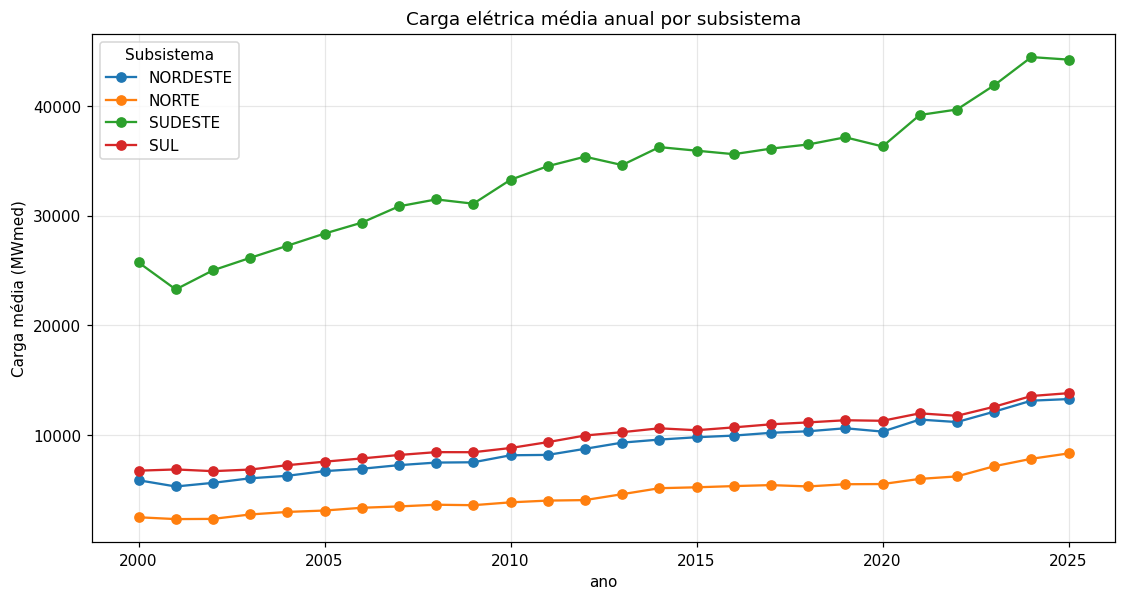

In [11]:
annual_load.plot(figsize = (12,6), marker = 'o')

plt.title('Carga elétrica média anual por subsistema')
plt.xlabel('ano')
plt.ylabel('Carga média (MWmed)')
plt.legend(title = 'Subsistema')
plt.grid(alpha = 0.3)
plt.show()

O gráfico mostra uma tendência de crescimento nos quatro subsistemas, mas esse aumento não aconteceu todos os anos.

O Sudeste permaneceu com a maior carga durante todo o período. Sua média passou de aproximadamente 25,7 mil MWmed em 2000 para 44,2 mil MWmed em 2025. Depois aparecem Sul, Nordeste e Norte.

Também existem anos de queda ou estabilidade. Em 2020, por exemplo, Nordeste, Sul e Sudeste apresentaram redução, enquanto o Norte ficou praticamente estável. Depois disso, as cargas voltaram a crescer.

Em 2025, Norte, Nordeste e Sul cresceram em relação a 2024. O Sudeste apresentou uma pequena redução.

Como a carga do Sudeste é muito maior, o gráfico dificulta a comparação do crescimento proporcional. Para resolver isso, vamos colocar todos os subsistemas no mesmo ponto de partida.

### 6.1. Crescimento Relativo por Subsistema

O ano de 2000 será utilizado como base 100:

- 100 representa o mesmo nível de 2000;
- 150 representa uma carga 50% maior;
- 200 representa o dobro do valor inicial.

Esse índice não representa MWmed. Ele serve apenas para comparar o crescimento proporcional.


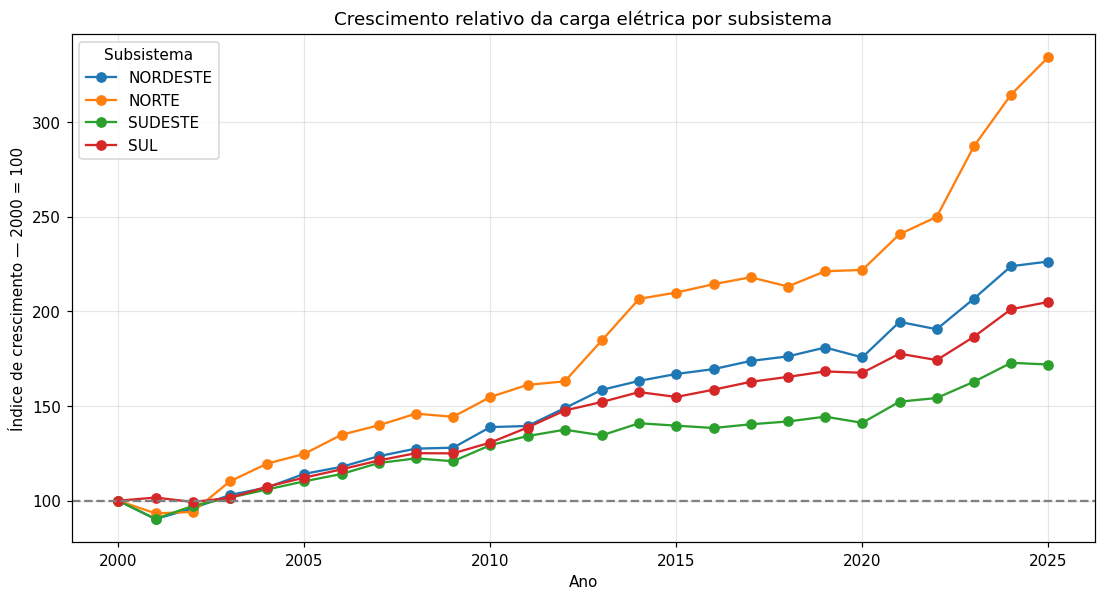

In [12]:
relative_growth = (annual_load / annual_load.loc[2000]) * 100

relative_growth.plot(figsize = (12,6), marker = 'o')

plt.title('Crescimento relativo da carga elétrica por subsistema')
plt.xlabel('Ano')
plt.ylabel('Índice de crescimento — 2000 = 100')
plt.legend(title='Subsistema')
plt.axhline(100, color='gray', linestyle='--')
plt.grid(alpha=0.3)
plt.show()

In [13]:
growth_2000_2025 = ((annual_load.loc[2025] / annual_load.loc[2000]) - 1) * 100

growth_2000_2025.sort_values(ascending = False).round(2)

nom_subsistema
NORTE       234.21
NORDESTE    126.28
SUL         104.92
SUDESTE      71.91
dtype: float64

O Norte apresentou o maior crescimento proporcional entre 2000 e 2025. Sua carga média aumentou 234,21%, chegando a aproximadamente 3,34 vezes o valor inicial.

O Nordeste cresceu 126,28%, o Sul 104,92% e o Sudeste 71,91%.

Portanto, o Sudeste continua com a maior carga em valores absolutos, mas foi o subsistema que menos cresceu proporcionalmente. O Norte possui a menor carga, mas teve o maior crescimento relativo.

Esse resultado também ajuda a entender o coeficiente de variação do Norte. Parte de sua dispersão pode estar relacionada à mudança no nível da série durante os anos.

Também precisamos considerar que a área atendida pelo SIN mudou nesse período. Segundo o ONS, o Amazonas foi integrado ao sistema em julho de 2013. Por isso, uma parte da elevação do Norte pode estar ligada à entrada dessa carga na série.

Fonte: [ONS — Interligação Tucuruí–Manaus–Macapá](https://www.ons.org.br/sites/multimidia/Documentos%20Compartilhados/dados/dados_relevantes_2013/HTML/01-07-destaques.html)

## 7. Construção da Série do SIN

Até aqui, os subsistemas foram analisados separadamente. Agora, vamos criar a carga do Sistema Interligado Nacional somando os quatro valores de cada horário.

Primeiro, os dados serão reorganizados para que cada linha represente um horário e cada coluna represente um subsistema. A soma só será feita quando as quatro cargas estiverem disponíveis.


In [14]:
hourly_load = electric_data.pivot(index = 'din_instante',
                                  columns = 'id_subsistema',
                                  values = 'val_cargaenergiahomwmed')

hourly_load.head()

id_subsistema,N,NE,S,SE
din_instante,,,,
2000-01-01 00:00:00,2373.7,5340.2,5777.0,21183.0
2000-01-01 01:00:00,2331.6,5180.8,5580.7,20409.9
2000-01-01 02:00:00,2332.9,5068.6,5098.7,19787.4
2000-01-01 03:00:00,2311.6,4905.1,4753.7,19089.0
2000-01-01 04:00:00,2287.8,4811.7,4584.1,18589.1


In [15]:
hourly_load['carga_sin'] = hourly_load[['N', 'NE', 'S', 'SE']].sum(axis = 1, min_count = 4)
hourly_load.head()

id_subsistema,N,NE,S,SE,carga_sin
din_instante,,,,,
2000-01-01 00:00:00,2373.7,5340.2,5777.0,21183.0,34673.9
2000-01-01 01:00:00,2331.6,5180.8,5580.7,20409.9,33503.0
2000-01-01 02:00:00,2332.9,5068.6,5098.7,19787.4,32287.6
2000-01-01 03:00:00,2311.6,4905.1,4753.7,19089.0,31059.4
2000-01-01 04:00:00,2287.8,4811.7,4584.1,18589.1,30272.7


In [16]:
hourly_load['carga_sin'].isna().sum()

np.int64(77)

In [17]:
missing_sin = hourly_load[hourly_load['carga_sin'].isna()]
missing_sin.head()

id_subsistema,N,NE,S,SE,carga_sin
din_instante,,,,,
2013-12-01 00:00:00,NaN,NaN,NaN,NaN,NaN
2013-12-01 01:00:00,NaN,NaN,NaN,NaN,NaN
2013-12-01 02:00:00,NaN,NaN,NaN,NaN,NaN
2013-12-01 03:00:00,NaN,NaN,NaN,NaN,NaN
2013-12-01 04:00:00,NaN,NaN,NaN,NaN,NaN


In [18]:
missing_sin[['N', 'NE', 'S', 'SE']].isna().sum()

id_subsistema
N     77
NE    77
S     77
SE    77
dtype: int64

Foram encontrados 77 horários em que a carga total não pôde ser calculada.

A tabela também mostra valores ausentes nas quatro colunas de subsistema. Portanto, nesses horários não ficou disponível apenas uma parte da carga: os quatro valores necessários para a soma estão ausentes.

Mesmo assim, o resultado do pivot não mostra se a linha existia com carga nula ou se ela não existia na base original. Primeiro, vamos verificar em quais datas esses 77 horários aparecem.


In [19]:
missing_sin_by_date = missing_sin.reset_index()

missing_sin_by_date['data'] = (missing_sin_by_date['din_instante'].dt.date)
missing_sin_by_date.groupby('data')['din_instante'].agg(['count', 'min', 'max'])

,count,min,max
data,,,
2013-12-01,24,2013-12-01,2013-12-01 23:00:00
2014-02-01,24,2014-02-01,2014-02-01 23:00:00
2014-10-19,1,2014-10-19,2014-10-19 00:00:00
2015-04-09,24,2015-04-09,2015-04-09 23:00:00
2015-10-18,1,2015-10-18,2015-10-18 00:00:00
2016-10-16,1,2016-10-16,2016-10-16 00:00:00
2017-10-15,1,2017-10-15,2017-10-15 00:00:00
2018-11-04,1,2018-11-04,2018-11-04 00:00:00


Os 77 horários estão distribuídos em oito datas.

Em 01/12/2013, 01/02/2014 e 09/04/2015, a carga total ficou ausente durante as 24 horas do dia. Juntas, essas datas representam 72 horários.

Nas outras cinco datas, apenas o horário de 00:00 ficou ausente. Somando esses cinco casos aos 72 anteriores, chegamos aos 77 horários encontrados.

Quando a coluna min mostra somente a data, ela está representando 00:00:00. O horário não aparece porque está exatamente à meia-noite.

Agora, precisamos verificar quais registros realmente existem na base original.


In [20]:
records_at_missing_times = electric_data[electric_data['din_instante'].isin(missing_sin.index)].copy()
records_at_missing_times['data'] = (records_at_missing_times['din_instante'].dt.date)
records_at_missing_times.groupby(['data', 'id_subsistema']).size().unstack(fill_value = 0)

id_subsistema,N,NE,S,SE
data,,,,
2013-12-01,24,24,24,24
2014-02-01,0,24,24,24
2014-10-19,1,1,1,1
2015-04-09,0,24,24,24
2015-10-18,1,1,1,1
2016-10-16,1,1,1,1
2017-10-15,1,1,1,1
2018-11-04,1,1,1,1


A consulta mostrou que o Norte não possui registros em 01/02/2014 e 09/04/2015. Nos outros subsistemas, existem 24 linhas em cada uma dessas datas.

Nas demais datas, os quatro subsistemas possuem registros. Porém, ainda precisamos confirmar se todas essas linhas estão com a carga nula.


In [21]:
records_at_missing_times.shape[0]

260

In [22]:
records_at_missing_times['val_cargaenergiahomwmed'].isna().sum()

np.int64(260)

Em 77 horários, seriam esperados 308 registros, considerando quatro subsistemas por horário.

A consulta encontrou 260 linhas na base original e todas possuem carga nula. As outras 48 linhas não existem e correspondem às 24 horas do Norte em 01/02/2014 e às 24 horas de 09/04/2015.

Com isso, temos duas situações:

- 260 registros existentes com carga nula;
- 48 registros do Norte que não aparecem na base.

Essa diferença explica por que 260 cargas nulas resultaram em 77 horários sem carga total depois da reorganização.


In [23]:
expected_hours = pd.date_range(
    start=hourly_load.index.min(),
    end=hourly_load.index.max(),
    freq='h'
)

absent_hours = expected_hours.difference(
    hourly_load.index
)

len(absent_hours)

14

In [24]:
absent_hours

DatetimeIndex(['2000-10-08', '2001-10-14', '2002-11-03', '2003-10-19',
               '2004-11-02', '2005-10-16', '2006-11-05', '2007-10-14',
               '2008-10-19', '2009-10-18', '2010-10-17', '2011-10-16',
               '2012-10-21', '2013-10-20'],
              dtype='datetime64[ns]', freq=None)

Além dos 77 horários existentes sem carga total, encontramos 14 horários que não aparecem no resultado do pivot.

Todos ocorrem às 00:00, uma vez por ano, entre outubro e novembro de 2000 a 2013. Ao comparar as datas com os registros oficiais, vimos que elas correspondem ao início do horário de verão.

Entre 2000 e 2013, nenhuma linha foi registrada nesses horários. Entre 2014 e 2018, a linha passou a existir, mas sem carga válida.

Por isso, esses casos serão tratados como uma característica da mudança de horário. Já os três dias completos continuam classificados como períodos sem informação válida na base.

Fonte: [Ministério de Minas e Energia — Horário de Verão](https://www.gov.br/mme/pt-br/assuntos/secretarias/secretaria-nacional-energia-eletrica/horario-de-verao)


In [25]:
valid_hours = hourly_load['carga_sin'].notna().sum()

unavailable_hours = (
    hourly_load['carga_sin'].isna().sum()
    + len(absent_hours)
)

coverage_percentage = (
    valid_hours / len(expected_hours) * 100
)

print(f'Horários esperados: {len(expected_hours):,}')
print(f'Horários com carga válida: {valid_hours:,}')
print(f'Horários indisponíveis: {unavailable_hours:,}')
print(f'Cobertura da série: {coverage_percentage:.3f}%')

Horários esperados: 227,928
Horários com carga válida: 227,837
Horários indisponíveis: 91
Cobertura da série: 99.960%


### 7.1. Cobertura da Série do SIN

Entre os 227.928 horários esperados, 227.837 possuem carga total válida. Foram encontrados 91 horários indisponíveis, resultando em uma cobertura de 99,960%.

Esses 91 horários são formados por:

- 72 horas dos três dias completos sem carga válida;
- 19 horas relacionadas ao início do horário de verão.

Portanto, apenas 0,040% dos horários não possuem carga total.

Nesta análise exploratória, os valores continuarão ausentes. Como representam uma parcela muito pequena do período, não devem alterar de forma importante as médias anuais e mensais.

No próximo notebook, será necessário tratar os três dias vazios para criar uma sequência diária regular.

### 7.2. Estatísticas Descritivas da Carga Total

Agora, vamos calcular as principais medidas estatísticas da carga do SIN para conhecer sua média, dispersão e faixa de valores.


In [26]:
sin_statistics = hourly_load['carga_sin'].describe().round(2)

sin_statistics

count    227837.00
mean      57042.63
std       14056.38
min       22601.86
25%       46313.47
50%       56291.63
75%       67144.33
max      106148.66
Name: carga_sin, dtype: float64

A série do SIN possui 227.837 horários com carga total válida, a mesma quantidade encontrada na verificação de cobertura.

A carga média foi de 57.042,63 MWmed e a mediana foi de 56.291,63 MWmed. Como os dois valores estão próximos, o centro da distribuição não parece ser muito afetado pelos extremos.

Metade dos registros está entre 46.313,47 e 67.144,33 MWmed. O desvio-padrão foi de 14.056,38 MWmed.

A menor carga foi de 22.601,86 MWmed e a maior chegou a 106.148,66 MWmed. Essa distância pode ter relação com os 26 anos de crescimento e com as variações mensais, semanais e horárias. Mais adiante, vamos localizar esses extremos no tempo.

### 7.3. Evolução Anual da Carga Total

Para observar a mudança no nível da carga, vamos calcular a média anual do SIN.


In [27]:
annual_sin = hourly_load.groupby(
    hourly_load.index.year
)['carga_sin'].mean()

annual_sin.index.name = 'ano'

annual_sin.round(2)

ano
2000    40812.38
2001    37729.60
2002    39667.80
2003    41764.51
2004    43731.71
2005    45713.57
2006    47471.22
2007    49730.61
2008    51008.11
2009    50598.08
2010    54061.77
2011    56029.85
2012    58100.14
2013    58744.33
2014    61555.06
2015    61353.78
2016    61551.74
2017    62681.42
2018    63255.71
2019    64581.11
2020    63408.47
2021    68525.44
2022    68797.20
2023    73704.99
2024    78943.25
2025    79608.91
Name: carga_sin, dtype: float64

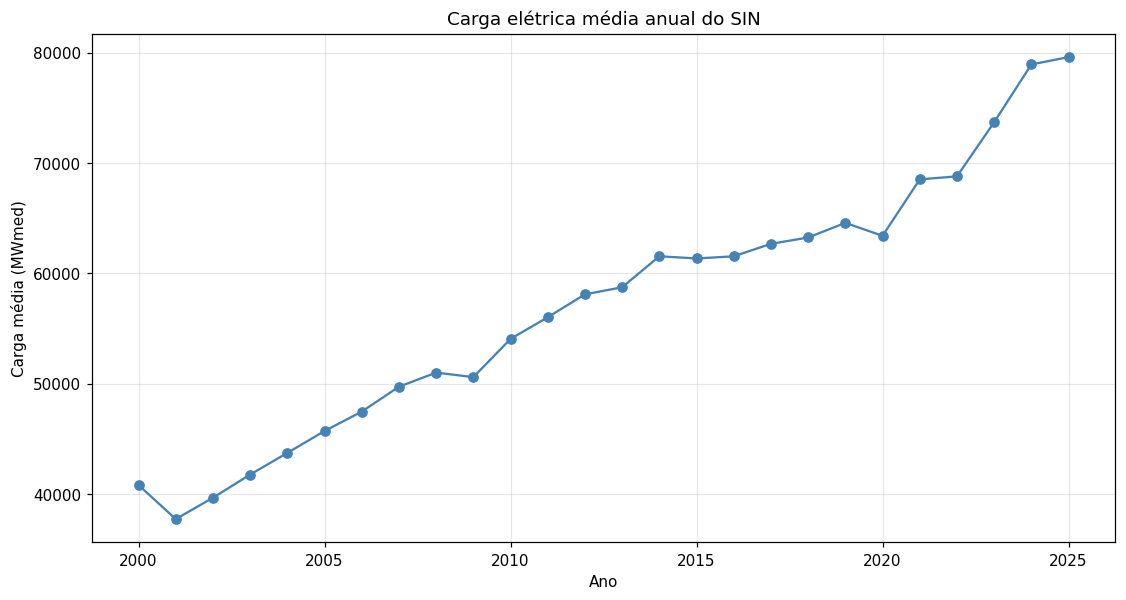

In [28]:
annual_sin.plot(
    figsize=(12, 6),
    marker='o',
    color='steelblue'
)

plt.title('Carga elétrica média anual do SIN')
plt.xlabel('Ano')
plt.ylabel('Carga média (MWmed)')
plt.grid(alpha=0.3)
plt.show()

A carga média anual do SIN apresenta crescimento no longo prazo. O valor de 2025 está próximo do dobro do início da série.

O crescimento não foi constante. Em 2001 houve uma queda forte, seguida por recuperação nos anos seguintes. Também aparecem uma pequena redução em 2009, estabilidade entre 2014 e 2016 e uma nova queda em 2020.

A carga voltou a crescer em 2021, com avanços maiores entre 2022 e 2024. Em 2025, a variação foi menor.

Essa evolução ajuda a explicar por que os histogramas possuem faixas tão amplas. Os primeiros anos estavam em um nível de carga bem menor que os anos recentes.

Agora, vamos calcular a variação percentual de cada ano para medir melhor essas mudanças.

### 7.4. Variação Percentual Anual

Valores positivos representarão crescimento em relação ao ano anterior e valores negativos representarão redução.


In [29]:
annual_variation = annual_sin.pct_change() * 100

annual_variation.round(2)

ano
2000     NaN
2001   -7.55
2002    5.14
2003    5.29
2004    4.71
2005    4.53
2006    3.84
2007    4.76
2008    2.57
2009   -0.80
2010    6.85
2011    3.64
2012    3.69
2013    1.11
2014    4.78
2015   -0.33
2016    0.32
2017    1.84
2018    0.92
2019    2.10
2020   -1.82
2021    8.07
2022    0.40
2023    7.13
2024    7.11
2025    0.84
Name: carga_sin, dtype: float64

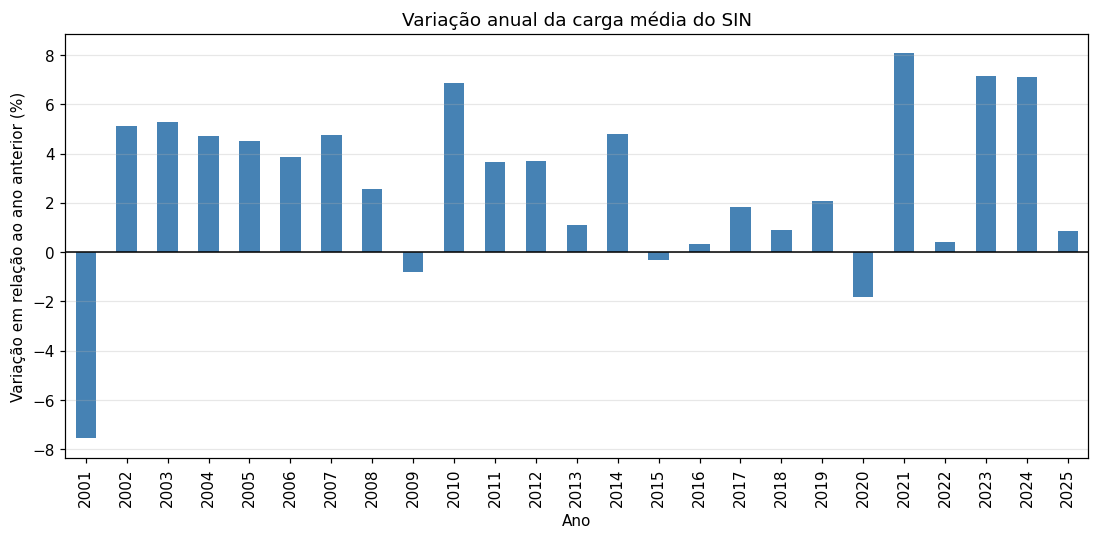

In [30]:
annual_variation.dropna().plot(
    kind='bar',
    figsize=(12, 5),
    color='steelblue'
)

plt.title('Variação anual da carga média do SIN')
plt.xlabel('Ano')
plt.ylabel('Variação em relação ao ano anterior (%)')
plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', alpha=0.3)
plt.show()

A carga média cresceu na maior parte do período. Entre os 25 anos que podem ser comparados, apenas quatro apresentaram redução.

A maior queda ocorreu em 2001, com redução de 7,55%. O período coincide com o racionamento de energia no país. Esse contexto ajuda na interpretação, mas o dataset sozinho não permite afirmar que essa foi a única causa.

Em 2020, a carga caiu 1,82%. O ONS registrou impactos das restrições da pandemia sobre a carga do sistema naquele ano.

O maior crescimento aconteceu em 2021, com 8,07%. Esse resultado reúne a recuperação em relação a 2020 e uma mudança na composição dos dados divulgados pelo ONS.

Em 2023 e 2024, os aumentos ficaram acima de 7%. A partir de abril de 2023, o ONS também passou a incorporar estimativas de micro e minigeração distribuída.

Por isso, as variações mais recentes não devem ser lidas apenas como aumento do consumo. Mudanças na metodologia também fazem parte dessa comparação.

Fontes consultadas:

- [EPE — PNE 2030: Análise Retrospectiva](https://www.epe.gov.br/sites-pt/publicacoes-dados-abertos/publicacoes/PublicacoesArquivos/publicacao-165/topico-173/PNE%202030%20-%20An%C3%A1lise%20Retrospectiva.pdf)
- [ONS — Boletim Mensal de Carga de abril de 2020](https://www.ons.org.br/AcervoDigitalDocumentosEPublicacoes/BoletimMensalCarga_abril-2020%20%28002%29.pdf)
- [ONS — Histórico da Carga de Energia](https://www.ons.org.br/Paginas/resultados-da-operacao/historico-da-operacao/carga_energia.aspx)


In [31]:
total_growth_sin = (
    (annual_sin.loc[2025] / annual_sin.loc[2000]) - 1
) * 100

average_annual_growth = (
    (
        annual_sin.loc[2025]
        / annual_sin.loc[2000]
    ) ** (1 / 25) - 1
) * 100

print(f'Crescimento entre 2000 e 2025: {total_growth_sin:.2f}%')
print(f'Crescimento médio anual: {average_annual_growth:.2f}%')

Crescimento entre 2000 e 2025: 95.06%
Crescimento médio anual: 2.71%


Entre 2000 e 2025, a carga média anual do SIN cresceu 95,06%.

A taxa média composta foi de 2,71% ao ano. Isso não significa que a carga aumentou 2,71% todos os anos. O valor apenas resume o crescimento necessário para sair do nível de 2000 e chegar ao de 2025.

Como vimos no gráfico, existiram anos de queda, estabilidade e crescimento mais forte.

## 8. Participação dos Subsistemas na Carga do SIN

Como os subsistemas cresceram em ritmos diferentes, vamos verificar se a participação de cada um na carga total também mudou.

Para isso, a carga de cada subsistema será dividida pela carga do SIN no mesmo horário. Depois, será calculada a participação média de cada ano.


In [32]:
subsystems = ['N', 'NE', 'S', 'SE']

hourly_share = hourly_load[subsystems].copy()

In [33]:
for subsystem in subsystems:

    hourly_share[subsystem] = (
        hourly_share[subsystem]
        / hourly_load['carga_sin']
        * 100
    )

In [34]:
hourly_share.head()

id_subsistema,N,NE,S,SE
din_instante,,,,
2000-01-01 00:00:00,6.845783,15.401210,16.660947,61.092061
2000-01-01 01:00:00,6.959377,15.463690,16.657314,60.919619
2000-01-01 02:00:00,7.225374,15.698287,15.791511,61.284828
2000-01-01 03:00:00,7.442513,15.792642,15.305189,61.459655
2000-01-01 04:00:00,7.557304,15.894519,15.142686,61.405491


In [35]:
annual_share = hourly_share.groupby(
    hourly_share.index.year
).mean()

annual_share.index.name = 'ano'

annual_share.round(2)

id_subsistema,N,NE,S,SE
ano,,,,
2000,6.18,14.43,16.41,62.98
2001,6.26,14.09,18.15,61.50
2002,5.98,14.25,16.79,62.98
2003,6.65,14.55,16.27,62.53
2004,6.89,14.41,16.44,62.25
2005,6.88,14.73,16.43,61.97
2006,7.16,14.63,16.44,61.76
2007,7.08,14.63,16.31,61.97
2008,7.21,14.73,16.41,61.64


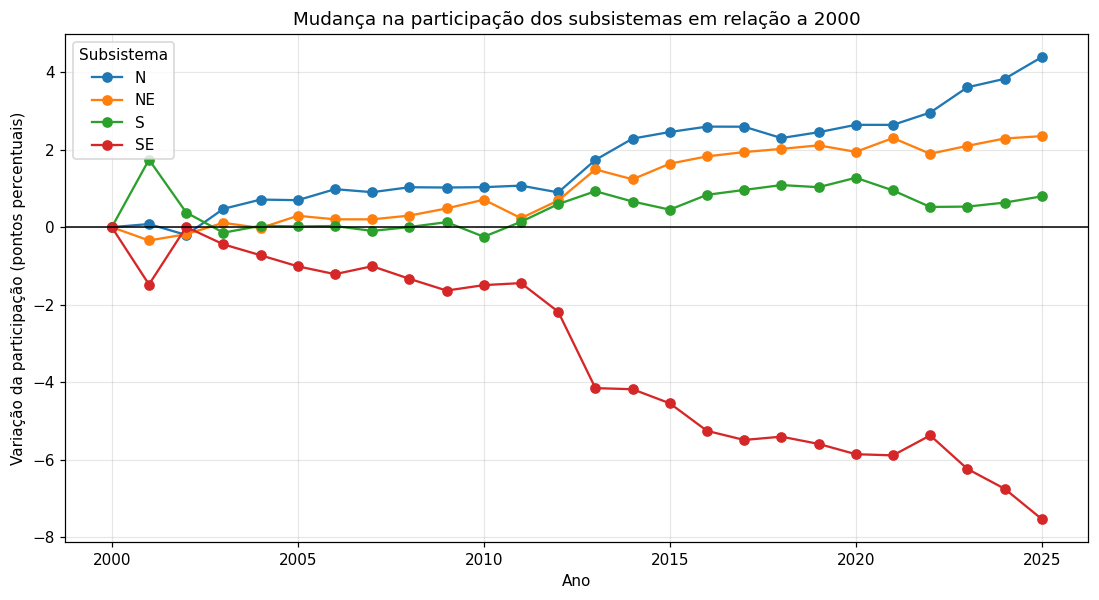

In [36]:
share_variation = annual_share - annual_share.loc[2000]

share_variation.plot(
    figsize=(12, 6),
    marker='o'
)

plt.title('Mudança na participação dos subsistemas em relação a 2000')
plt.xlabel('Ano')
plt.ylabel('Variação da participação (pontos percentuais)')
plt.axhline(0, color='black', linewidth=1)
plt.legend(title='Subsistema')
plt.grid(alpha=0.3)
plt.show()

O gráfico utiliza 2000 como ponto de partida.

Valores acima de zero representam ganho de participação em relação ao primeiro ano. Valores abaixo de zero representam perda.

Agora, vamos comparar diretamente os resultados de 2000 e 2025.


In [37]:
share_comparison = annual_share.loc[[2000, 2025]].T.copy()

share_comparison.columns = ['participacao_2000', 'participacao_2025']
share_comparison['variacao_pp'] = (
    share_comparison['participacao_2025']
    - share_comparison['participacao_2000']
)

share_comparison.round(2)

,participacao_2000,participacao_2025,variacao_pp
id_subsistema,,,
N,6.18,10.57,4.39
NE,14.43,16.78,2.35
S,16.41,17.20,0.80
SE,62.98,55.44,-7.53


O Sudeste continuou sendo o maior componente do SIN, mas sua participação média caiu de 62,98% em 2000 para 55,44% em 2025. A redução foi de 7,53 pontos percentuais.

O Norte apresentou o maior ganho, passando de 6,18% para 10,57%. O aumento foi de 4,39 pontos percentuais. O Nordeste ganhou 2,35 pontos e o Sul ganhou 0,80 ponto.

Isso não quer dizer que a carga do Sudeste diminuiu. Ela cresceu em MWmed, mas em um ritmo menor que os outros subsistemas.

## 9. Sazonalidade Mensal da Carga

Depois da tendência anual, vamos observar as médias mensais. Essa redução facilita a visualização de movimentos que se repetem dentro dos anos.


In [38]:
monthly_sin = hourly_load['carga_sin'].resample('ME').mean()

monthly_sin.head()

din_instante
2000-01-31    39253.390659
2000-02-29    40665.397845
2000-03-31    40556.063720
2000-04-30    40214.947917
2000-05-31    40408.382258
Freq: ME, Name: carga_sin, dtype: float64

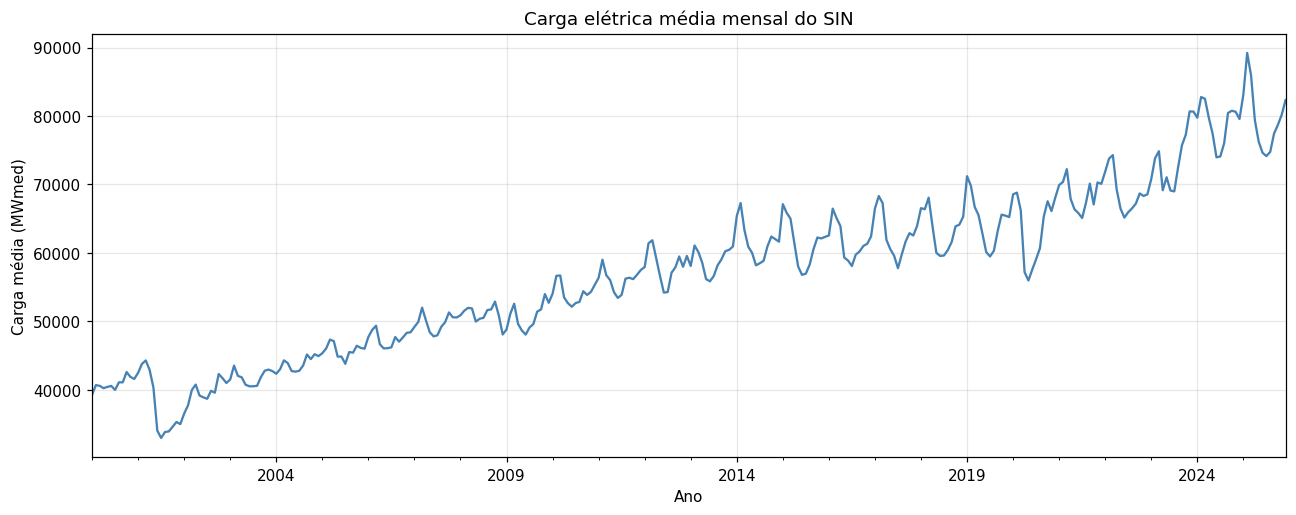

In [39]:
monthly_sin.plot(
    figsize=(14, 5),
    color='steelblue'
)

plt.title('Carga elétrica média mensal do SIN')
plt.xlabel('Ano')
plt.ylabel('Carga média (MWmed)')
plt.grid(alpha=0.3)
plt.show()

A série mensal mantém o crescimento de longo prazo e também mostra oscilações dentro dos anos.

Porém, comparar todos os meses diretamente em MWmed mistura dois efeitos: o crescimento da série e a sazonalidade mensal.

Para reduzir esse problema, cada média mensal será comparada com a média do próprio ano. O resultado será um índice em que 100 representa a média anual.


In [40]:
monthly_analysis = monthly_sin.to_frame(name='carga_media')

monthly_analysis['ano'] = monthly_analysis.index.year
monthly_analysis['mes'] = monthly_analysis.index.month
monthly_analysis['media_anual'] = monthly_analysis.groupby('ano')['carga_media'].transform('mean')
monthly_analysis['indice_sazonal'] = (
    monthly_analysis['carga_media']
    / monthly_analysis['media_anual']
    * 100
)

month_names = {
    1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr',
    5: 'Mai', 6: 'Jun', 7: 'Jul', 8: 'Ago',
    9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'
}

monthly_seasonality = monthly_analysis.groupby('mes')['indice_sazonal'].mean()
monthly_seasonality.index = monthly_seasonality.index.map(month_names)

monthly_seasonality.round(2)

mes
Jan    101.71
Fev    104.60
Mar    104.45
Abr    100.20
Mai     96.98
Jun     95.15
Jul     95.03
Ago     97.35
Set     99.61
Out    101.40
Nov    101.69
Dez    101.84
Name: indice_sazonal, dtype: float64

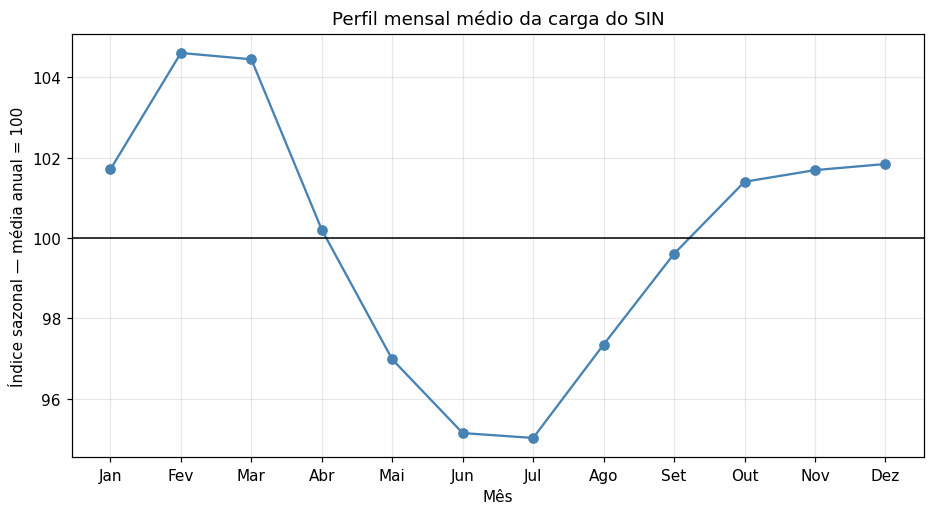

In [41]:
monthly_seasonality.plot(
    figsize=(10, 5),
    marker='o',
    color='steelblue'
)

plt.title('Perfil mensal médio da carga do SIN')
plt.xlabel('Mês')
plt.ylabel('Índice sazonal — média anual = 100')
plt.xticks(range(12), monthly_seasonality.index)
plt.axhline(100, color='black', linewidth=1)
plt.grid(alpha=0.3)
plt.show()

Fevereiro e março apresentam os maiores índices, com 104,60 e 104,45. Em média, esses meses ficaram cerca de 4,6% e 4,5% acima da média de seus anos.

Os menores valores aparecem em junho e julho, com índices próximos de 95. Isso representa aproximadamente 5% abaixo da média anual.

Entre outubro e dezembro, a carga volta a ficar acima de 100.

Esse é o perfil médio dos 26 anos. Alguns anos podem apresentar comportamentos diferentes.

### 9.1. Sazonalidade Mensal por Subsistema

Agora, vamos calcular o mesmo índice para cada subsistema e verificar se as regiões seguem o mesmo padrão mensal.


In [42]:
subsystem_monthly = (
    electric_data
    .assign(mes=electric_data['din_instante'].dt.month)
    .groupby(['ano', 'mes', 'nom_subsistema'])['val_cargaenergiahomwmed']
    .mean()
    .reset_index()
)

subsystem_monthly['media_anual'] = (
    subsystem_monthly
    .groupby(['ano', 'nom_subsistema'])['val_cargaenergiahomwmed']
    .transform('mean')
)

subsystem_monthly['indice_sazonal'] = (
    subsystem_monthly['val_cargaenergiahomwmed']
    / subsystem_monthly['media_anual']
    * 100
)

subsystem_seasonality = (
    subsystem_monthly
    .groupby(['mes', 'nom_subsistema'])['indice_sazonal']
    .mean()
    .unstack()
)

subsystem_seasonality.index = subsystem_seasonality.index.map(month_names)

subsystem_seasonality.round(2)

nom_subsistema,NORDESTE,NORTE,SUDESTE,SUL
mes,,,,
Jan,99.97,95.80,102.10,105.08
Fev,100.98,96.84,105.42,108.95
Mar,101.84,98.34,105.47,106.32
Abr,100.23,98.93,100.71,99.00
Mai,99.02,99.89,96.55,95.26
Jun,95.37,99.17,94.47,95.39
Jul,94.87,98.68,94.23,96.07
Ago,96.79,102.02,97.04,96.47
Set,99.81,103.46,100.07,95.88


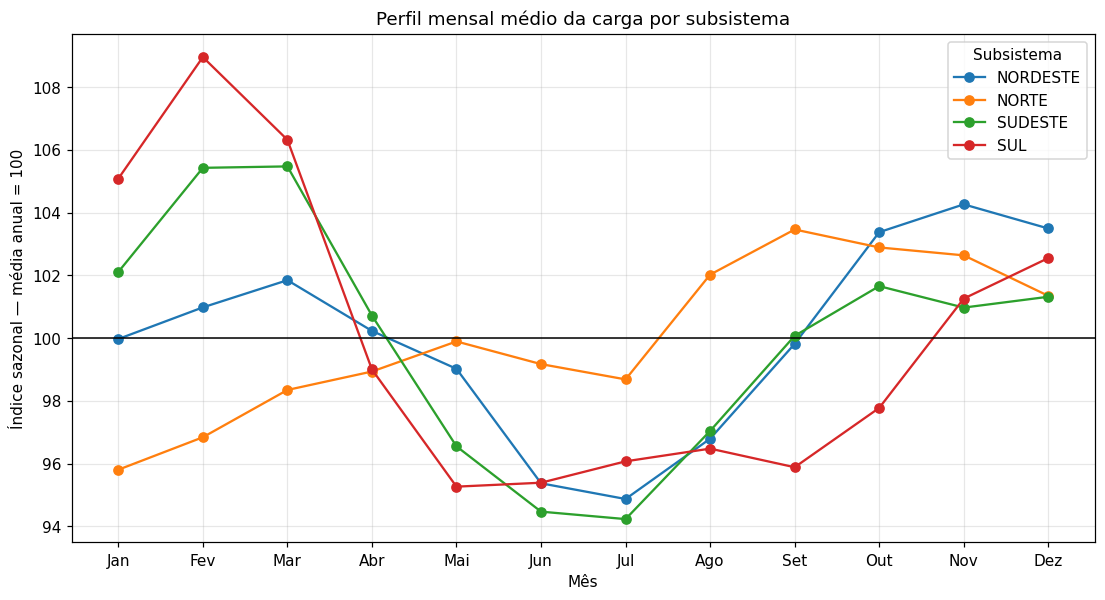

In [43]:
subsystem_seasonality.plot(
    figsize=(12, 6),
    marker='o'
)

plt.title('Perfil mensal médio da carga por subsistema')
plt.xlabel('Mês')
plt.ylabel('Índice sazonal — média anual = 100')
plt.xticks(range(12), subsystem_seasonality.index)
plt.axhline(100, color='black', linewidth=1)
plt.legend(title='Subsistema')
plt.grid(alpha=0.3)
plt.show()

Os quatro subsistemas não possuem o mesmo comportamento mensal.

Sul e Sudeste apresentam maiores índices em fevereiro e março e ficam abaixo da média principalmente entre maio e agosto.

No Nordeste, os menores valores aparecem em junho e julho, enquanto os maiores ficam entre outubro e dezembro.

O Norte possui um formato diferente. Janeiro e fevereiro ficam abaixo da média, e os maiores índices aparecem entre agosto e novembro.

Portanto, o comportamento mensal do SIN é uma combinação de padrões regionais diferentes. Para investigar as causas, seriam necessárias outras informações, como temperatura, chuva e atividade econômica.

## 10. Comportamento ao Longo da Semana

Agora, vamos calcular a carga média por dia da semana. Cada valor será comparado com a média do próprio ano para evitar que o crescimento histórico domine o resultado.


In [44]:
daily_sin = hourly_load['carga_sin'].resample('D').mean().to_frame('carga_media')

daily_sin['ano'] = daily_sin.index.year
daily_sin['dia_semana'] = daily_sin.index.dayofweek
daily_sin['media_anual'] = daily_sin.groupby('ano')['carga_media'].transform('mean')
daily_sin['indice_anual'] = (
    daily_sin['carga_media']
    / daily_sin['media_anual']
    * 100
)

day_names = {
    0: 'Segunda', 1: 'Terça', 2: 'Quarta',
    3: 'Quinta', 4: 'Sexta', 5: 'Sábado', 6: 'Domingo'
}

weekly_profile = daily_sin.groupby('dia_semana')['indice_anual'].mean()
weekly_profile.index = weekly_profile.index.map(day_names)

weekly_profile.round(2)

dia_semana
Segunda    101.51
Terça      104.00
Quarta     104.48
Quinta     104.37
Sexta      103.75
Sábado      95.57
Domingo     86.33
Name: indice_anual, dtype: float64

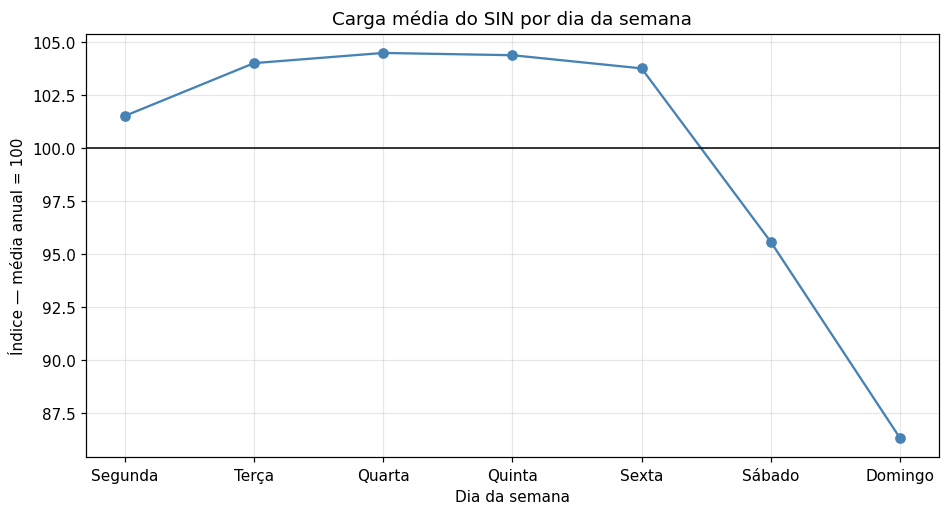

In [45]:
weekly_profile.plot(
    figsize=(10, 5),
    marker='o',
    color='steelblue'
)

plt.title('Carga média do SIN por dia da semana')
plt.xlabel('Dia da semana')
plt.ylabel('Índice — média anual = 100')
plt.xticks(range(7), weekly_profile.index)
plt.axhline(100, color='black', linewidth=1)
plt.grid(alpha=0.3)
plt.show()

O gráfico mostra um ciclo semanal bem definido.

Os maiores índices aparecem entre terça e quinta-feira, todos próximos de 104. A segunda-feira fica mais perto da média anual, com 101,51.

No fim de semana, a carga diminui. O sábado possui índice de 95,57 e o domingo chega a 86,33, sendo o menor valor da semana.

O resultado mostra que o dia da semana está relacionado ao nível da carga. Os feriados ainda não estão separados nessa análise e podem apresentar um comportamento próprio.

## 11. Comportamento ao Longo do Dia

Depois do ciclo semanal, vamos analisar as 24 horas do dia.

Dias úteis e finais de semana serão separados para verificar se suas curvas possuem formatos diferentes. Novamente, cada valor será comparado com a média do próprio ano.


In [46]:
hourly_profile = hourly_load[['carga_sin']].dropna().copy()

hourly_profile['ano'] = hourly_profile.index.year
hourly_profile['hora'] = hourly_profile.index.hour
hourly_profile['dia_semana'] = hourly_profile.index.dayofweek
hourly_profile['tipo_dia'] = 'Dia útil'

hourly_profile.loc[
    hourly_profile['dia_semana'] >= 5,
    'tipo_dia'
] = 'Fim de semana'

hourly_profile['media_anual'] = hourly_profile.groupby('ano')['carga_sin'].transform('mean')
hourly_profile['indice_anual'] = (
    hourly_profile['carga_sin']
    / hourly_profile['media_anual']
    * 100
)

typical_hour = (
    hourly_profile
    .groupby(['hora', 'tipo_dia'])['indice_anual']
    .mean()
    .unstack()
)

typical_hour.round(2)

tipo_dia,Dia útil,Fim de semana
hora,,
0,93.27,92.35
1,88.42,87.58
2,85.71,84.41
3,84.51,82.57
4,84.65,81.71
5,86.82,81.10
6,90.66,79.49
7,96.37,80.55
8,104.00,84.51


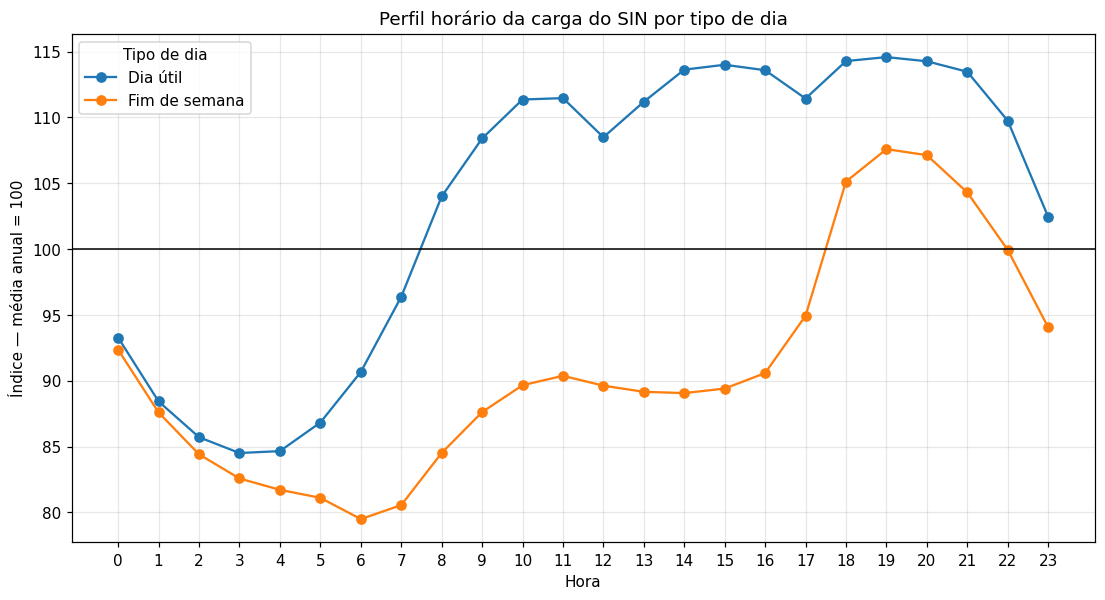

In [47]:
typical_hour.plot(
    figsize=(12, 6),
    marker='o'
)

plt.title('Perfil horário da carga do SIN por tipo de dia')
plt.xlabel('Hora')
plt.ylabel('Índice — média anual = 100')
plt.xticks(range(24))
plt.axhline(100, color='black', linewidth=1)
plt.legend(title='Tipo de dia')
plt.grid(alpha=0.3)
plt.show()

Nos dias úteis, a carga diminui durante a madrugada e atinge o menor índice por volta das 03:00.

A partir das 06:00, ela começa a subir rapidamente e permanece acima da média principalmente entre 08:00 e 22:00. O maior índice aparece às 19:00.

Nos finais de semana, a carga fica abaixo da média durante quase todo o dia. A maior diferença em relação aos dias úteis acontece no horário comercial. À noite, as curvas ficam mais próximas e o maior índice também aparece às 19:00.

Agora, vamos verificar se esse formato se repete nos quatro subsistemas.

### 11.1. Perfil Horário por Subsistema


In [48]:
subsystem_hourly = electric_data.dropna(
    subset=['val_cargaenergiahomwmed']
).copy()

subsystem_hourly['hora'] = subsystem_hourly['din_instante'].dt.hour
subsystem_hourly['media_anual'] = (
    subsystem_hourly
    .groupby(['ano', 'nom_subsistema'])['val_cargaenergiahomwmed']
    .transform('mean')
)
subsystem_hourly['indice_anual'] = (
    subsystem_hourly['val_cargaenergiahomwmed']
    / subsystem_hourly['media_anual']
    * 100
)

hourly_by_subsystem = (
    subsystem_hourly
    .groupby(['hora', 'nom_subsistema'])['indice_anual']
    .mean()
    .unstack()
)

hourly_by_subsystem.round(2)

nom_subsistema,NORDESTE,NORTE,SUDESTE,SUL
hora,,,,
0,98.89,102.45,91.51,88.45
1,95.49,100.34,86.24,82.69
2,93.30,98.61,83.22,79.37
3,91.95,97.18,81.82,78.07
4,91.27,96.09,81.90,78.08
5,88.87,95.21,84.19,80.75
6,85.63,92.10,87.64,86.40
7,89.29,91.06,92.04,93.90
8,95.74,94.48,98.51,102.43


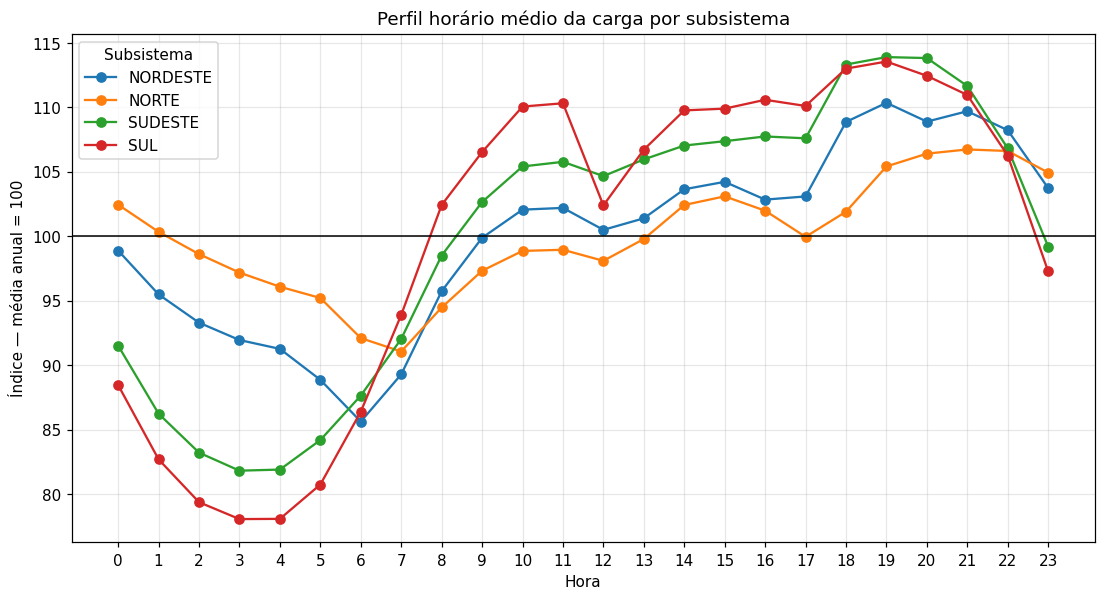

In [49]:
hourly_by_subsystem.plot(
    figsize=(12, 6),
    marker='o'
)

plt.title('Perfil horário médio da carga por subsistema')
plt.xlabel('Hora')
plt.ylabel('Índice — média anual = 100')
plt.xticks(range(24))
plt.axhline(100, color='black', linewidth=1)
plt.legend(title='Subsistema')
plt.grid(alpha=0.3)
plt.show()

Todos os subsistemas apresentam redução durante a madrugada e aumento ao longo do dia. Porém, a intensidade e o horário dessas mudanças são diferentes.

Sul e Sudeste possuem as maiores variações. Os menores índices aparecem entre 03:00 e 04:00, e os maiores ficam próximos das 19:00.

No Nordeste, o menor índice ocorre às 06:00 e o maior às 19:00.

O Norte apresenta a curva mais estável. Seu menor índice aparece às 07:00 e o maior ocorre mais tarde, às 21:00. A carga também permanece mais alta durante a madrugada quando comparada com sua própria média.

Dessa forma, a curva geral do SIN não representa perfeitamente todos os subsistemas.

## 12. Variabilidade da Carga ao Longo dos Anos

No início do notebook, o coeficiente de variação foi calculado com todos os anos juntos. Agora, vamos calcular essa medida para cada ano e subsistema.

Assim, poderemos observar se a variação proporcional da carga mudou ao longo do tempo.


In [50]:
annual_variability = (
    electric_data
    .groupby(['ano', 'nom_subsistema'])['val_cargaenergiahomwmed']
    .agg(['mean', 'std'])
)

annual_variability['cv_%'] = (
    annual_variability['std']
    / annual_variability['mean']
    * 100
)

annual_cv = annual_variability['cv_%'].unstack()

annual_cv.round(2)

nom_subsistema,NORDESTE,NORTE,SUDESTE,SUL
ano,,,,
2000,12.79,6.75,15.31,18.92
2001,17.12,11.54,19.66,19.57
2002,12.53,8.79,15.02,18.69
2003,11.28,6.87,14.67,18.87
2004,12.07,6.02,14.81,18.91
2005,11.43,6.45,14.94,18.90
2006,11.74,6.21,15.02,18.78
2007,11.69,6.29,14.63,19.16
2008,11.52,6.36,14.71,19.20


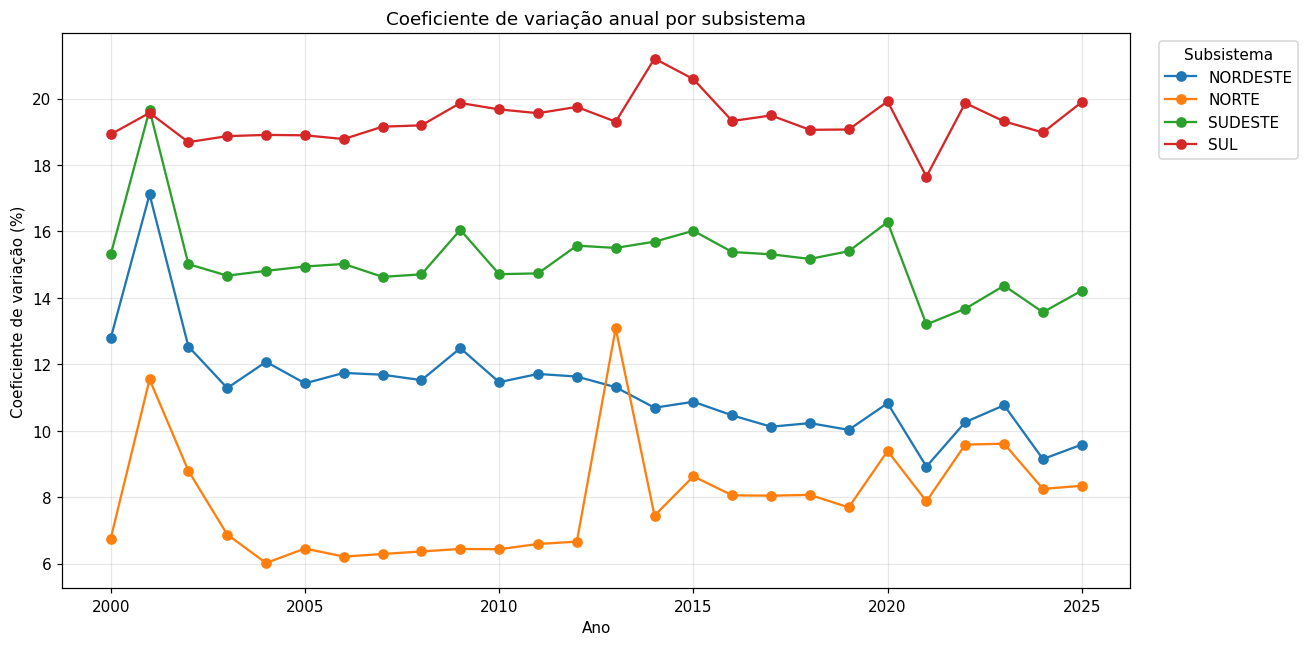

In [51]:
annual_cv.plot(
    figsize=(12, 6),
    marker='o'
)

plt.title('Coeficiente de variação anual por subsistema')
plt.xlabel('Ano')
plt.ylabel('Coeficiente de variação (%)')
plt.legend(
    title='Subsistema',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

O Sul apresentou a maior variação proporcional na maior parte do período, geralmente entre 18% e 21%. O Sudeste aparece em seguida. Nordeste e Norte possuem valores menores na maioria dos anos.

Não existe um movimento contínuo de aumento ou redução. Alguns anos apresentam elevações isoladas, como 2001 em vários subsistemas, 2013 no Norte e 2014 no Sul.

O resultado do Norte em 2013 ficou muito acima dos anos vizinhos. Para entender melhor essa diferença, vamos observar suas médias mensais naquele ano.


In [52]:
north_2013 = subsystem_monthly[
    (subsystem_monthly['ano'] == 2013)
    & (subsystem_monthly['nom_subsistema'] == 'NORTE')
][['mes', 'val_cargaenergiahomwmed']]

north_2013.round(2)

,mes,val_cargaenergiahomwmed
625,1,3955.97
629,2,4068.56
633,3,4218.49
637,4,4244.86
641,5,4215.81
645,6,4017.35
649,7,4637.35
653,8,5179.06
657,9,5188.62
661,10,5141.88


A média mensal do Norte muda de nível a partir de julho de 2013.

Em junho, a carga média era de aproximadamente 4.017 MWmed. Em julho, passou para 4.637 MWmed e chegou a 5.179 MWmed em agosto.

Essa mudança acontece no mesmo período da integração do Amazonas ao SIN, citada anteriormente.

Como 2013 reúne meses antes e depois dessa alteração, seu coeficiente de variação ficou mais alto. Nesse caso, a dispersão não representa apenas oscilações da carga, mas também uma mudança na abrangência da série.

## 13. Análise dos Valores Extremos

As estatísticas descritivas mostraram uma distância grande entre a menor e a maior carga do SIN.

Primeiro, vamos localizar os dez maiores registros e observar quando eles aconteceram.


In [53]:
largest_sin_loads = (
    hourly_load['carga_sin']
    .nlargest(10)
    .to_frame()
)

largest_sin_loads.round(2)

,carga_sin
din_instante,
2025-02-26 14:00:00,106148.66
2025-02-25 14:00:00,105314.79
2025-02-25 15:00:00,105184.59
2025-02-26 13:00:00,105152.44
2025-02-24 14:00:00,105123.00
2025-02-26 15:00:00,105092.43
2025-02-25 13:00:00,105036.29
2025-02-27 14:00:00,104895.86
2025-02-24 15:00:00,104721.93


Os dez maiores registros estão concentrados em fevereiro de 2025, principalmente entre 13:00 e 15:00.

O maior valor aconteceu em 26/02/2025 às 14:00, quando a carga total chegou a 106.148,66 MWmed.

Fevereiro já havia aparecido entre os meses com maiores índices, e o período da tarde também costuma ter carga elevada nos dias úteis. Mesmo assim, somente esta base não permite identificar o motivo específico desses picos.

Agora, vamos observar os dez menores valores do SIN.


In [54]:
smallest_sin_loads = (
    hourly_load['carga_sin']
    .nsmallest(10)
    .to_frame()
)

smallest_sin_loads.round(2)

,carga_sin
din_instante,
2001-12-25 07:00:00,22601.86
2001-07-29 07:00:00,22677.34
2002-01-01 07:00:00,22987.90
2001-07-29 06:00:00,23234.51
2001-12-25 06:00:00,23295.70
2001-07-01 07:00:00,23301.62
2001-07-15 07:00:00,23348.83
2002-01-01 08:00:00,23439.33
2001-12-25 08:00:00,23443.80


Os menores valores do SIN estão concentrados em 2001 e no início de 2002, quando o nível geral da carga ainda era bem menor que o atual.

Vários registros aconteceram entre 05:00 e 08:00, período que já apareceu com carga mais baixa. Também existem datas como Natal, Ano-Novo e alguns domingos.

A menor carga total foi registrada em 25/12/2001 às 07:00, com 22.601,86 MWmed.

### 13.1. Menor Valor de Cada Subsistema

O mínimo de 149,86 MWmed do Nordeste chamou atenção no início da análise. Agora, vamos localizar o menor valor dos quatro subsistemas.


In [55]:
minimum_records = electric_data.loc[
    electric_data
    .groupby('id_subsistema')['val_cargaenergiahomwmed']
    .idxmin(),
    [
        'id_subsistema',
        'nom_subsistema',
        'din_instante',
        'val_cargaenergiahomwmed'
    ]
].sort_values('id_subsistema')

minimum_records

,id_subsistema,nom_subsistema,din_instante,val_cargaenergiahomwmed
41448,N,NORTE,2001-03-07 19:00:00,610.400000
449425,NE,NORDESTE,2012-10-26 01:00:00,149.860000
104562,S,SUL,2002-12-25 07:00:00,3615.830005
72147,SE,SUDESTE,2002-01-21 14:00:00,7970.579997


Os menores valores aconteceram em datas e horários diferentes.

A tabela mostra onde eles ocorreram, mas ainda não permite saber se fazem parte de uma queda gradual ou se são pontos muito diferentes das horas próximas.

Para verificar isso, vamos observar quatro horas antes e quatro horas depois de cada mínimo.


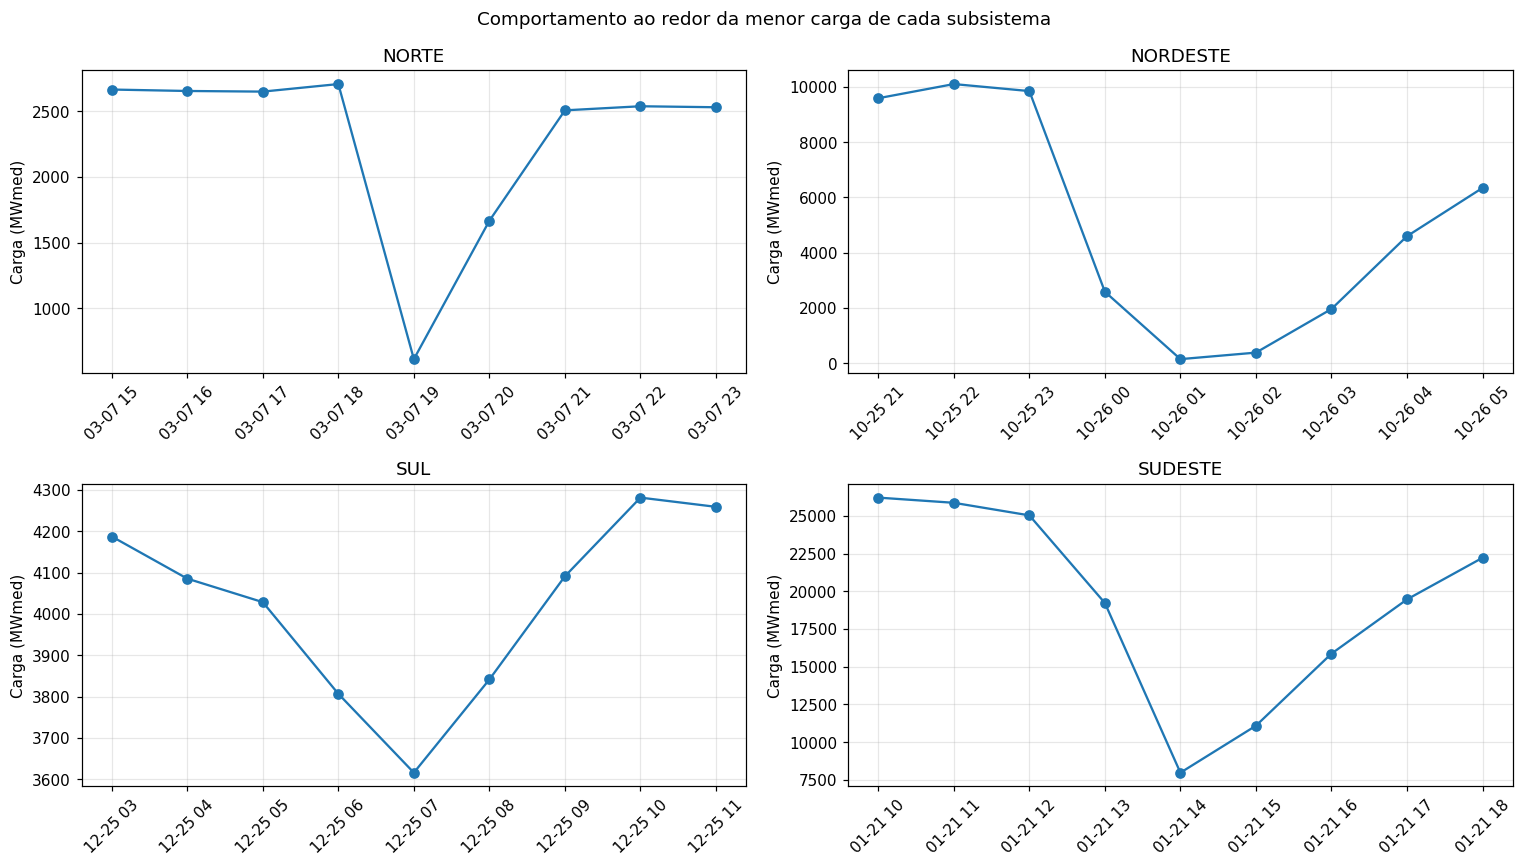

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (_, record) in zip(axes.flat, minimum_records.iterrows()):

    start_time = record['din_instante'] - pd.Timedelta(hours=4)
    end_time = record['din_instante'] + pd.Timedelta(hours=4)

    context = electric_data[
        (electric_data['id_subsistema'] == record['id_subsistema'])
        & (electric_data['din_instante'].between(start_time, end_time))
    ]

    ax.plot(
        context['din_instante'],
        context['val_cargaenergiahomwmed'],
        marker='o'
    )
    ax.set_title(record['nom_subsistema'])
    ax.set_ylabel('Carga (MWmed)')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)

fig.suptitle('Comportamento ao redor da menor carga de cada subsistema')
plt.tight_layout()
plt.show()

No Sul, o menor valor faz parte de uma redução mais gradual durante a manhã de 25/12/2002.

Norte, Nordeste e Sudeste apresentam quedas mais fortes em relação às horas próximas.

No Nordeste, a carga permanece muito baixa entre 00:00 e 03:00 de 26/10/2012. No Sudeste, a redução também dura algumas horas em 21/01/2002. No Norte, o menor valor aparece em uma queda mais curta em 07/03/2001.

Esses registros são diferentes do comportamento ao redor deles, mas os dados não mostram se representam falhas, indisponibilidades ou acontecimentos reais do sistema. Por isso, eles serão mantidos e apenas sinalizados na análise.

## 14. Relação Entre os Subsistemas

Como todas as séries cresceram ao longo do tempo, uma correlação calculada diretamente sobre as cargas poderia ficar alta apenas por causa dessa tendência.

Para reduzir esse efeito, vamos calcular a variação percentual das médias diárias e medir a correlação entre essas mudanças.


In [57]:
daily_subsystem_load = hourly_load[subsystems].resample('D').mean()
daily_subsystem_variation = daily_subsystem_load.pct_change(fill_method=None) * 100

subsystem_correlation = daily_subsystem_variation.corr()

subsystem_correlation.round(3)

id_subsistema,N,NE,S,SE
id_subsistema,,,,
N,1.000,0.863,0.888,0.890
NE,0.863,1.000,0.913,0.915
S,0.888,0.913,1.000,0.965
SE,0.890,0.915,0.965,1.000


Todas as correlações ficaram positivas e acima de 0,86. Isso mostra que as variações diárias dos subsistemas costumam seguir a mesma direção, embora não sejam iguais.

A relação mais forte aparece entre Sul e Sudeste, com 0,965. A menor aparece entre Norte e Nordeste, com 0,863.

A correlação não mostra que um subsistema causa a mudança do outro. Ela indica apenas que os aumentos e as reduções diárias possuem comportamentos parecidos.

## 15. Conclusão da Análise Exploratória

A análise exploratória mostrou os seguintes pontos:

- a carga média do SIN cresceu 95,06% entre 2000 e 2025;
- o Sudeste continuou com a maior carga, mas perdeu participação no total;
- o Norte apresentou o maior crescimento proporcional;
- fevereiro e março possuem os maiores índices mensais do SIN, enquanto junho e julho possuem os menores;
- a carga diminui nos finais de semana, principalmente aos domingos;
- nos dias úteis, ela cresce pela manhã e permanece elevada durante a tarde e o início da noite;
- os subsistemas possuem perfis mensais e horários diferentes;
- os maiores registros do SIN aconteceram em fevereiro de 2025;
- alguns valores mínimos regionais apresentaram quedas fortes em relação às horas próximas;
- as variações diárias dos subsistemas possuem correlações positivas altas;
- a série possui cobertura de 99,960% e as horas indisponíveis foram mantidas como ausentes.

Também vimos que a série passou por mudanças de abrangência e metodologia. Essas alterações precisam ser lembradas ao comparar períodos muito distantes.

### Próxima Etapa

No próximo notebook, vamos transformar a carga do SIN em uma série diária e analisar suas características estatísticas.

Antes de concluir qualquer resultado, serão verificados:

1. a regularidade da sequência diária;
2. o tratamento necessário para os três dias sem carga;
3. a mudança da média e da variabilidade ao longo do tempo;
4. a tendência e os ciclos semanal e anual;
5. a autocorrelação e a estacionariedade da série.

## 16. Fontes de Contexto

- [ONS — Histórico da Carga de Energia e mudanças metodológicas](https://www.ons.org.br/Paginas/resultados-da-operacao/historico-da-operacao/carga_energia.aspx)
- [ONS — Integração do Amazonas ao SIN em julho de 2013](https://www.ons.org.br/sites/multimidia/Documentos%20Compartilhados/dados/dados_relevantes_2013/HTML/01-07-destaques.html)
- [ONS — Boletim Mensal de Carga de abril de 2020](https://www.ons.org.br/AcervoDigitalDocumentosEPublicacoes/BoletimMensalCarga_abril-2020%20%28002%29.pdf)
- [EPE — PNE 2030: Análise Retrospectiva](https://www.epe.gov.br/sites-pt/publicacoes-dados-abertos/publicacoes/PublicacoesArquivos/publicacao-165/topico-173/PNE%202030%20-%20An%C3%A1lise%20Retrospectiva.pdf)
- [Ministério de Minas e Energia — Horário de Verão](https://www.gov.br/mme/pt-br/assuntos/secretarias/secretaria-nacional-energia-eletrica/horario-de-verao)
